<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; Klantsucces Analytics</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">Grondoorzaakanalyse van Klantverloop</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">PROC FISHBONE oorzaak-en-gevolgdiagram voor een retentiebeoordeling van B2B SaaS in het middensegment</div>
</div>

## Managementsamenvatting

Deze analyse organiseert de grondoorzaken van verhoogd SaaS-klantverloop in een
gestructureerd oorzaak-en-gevolgdiagram (Ishikawa). Het B2B-segment in het
middensegment verliest ongeveer 18% van de klanten per jaar tegenover een doel
van 8%. Twintig grondoorzaakbevindingen — afkomstig uit exit-interviews,
klantsuccesgesprekken en cohortattributie — zijn gegroepeerd in zes
oorzaakcategorieën en weergegeven met `PROC FISHBONE` als een diagram met 27
knooppunten (een gevolg, zes categoriebeenderen, twintig subhoorzaken).

De ondersteunende `PROC MEANS`-uitsplitsing toont waar het toewijsbare
klantverloop zich concentreert. **Product** heeft de meeste bevindingen (5
oorzaken, 48,1 totale impactpunten), gevolgd door **Prijsstelling** (4
oorzaken, 42,3) en **Ondersteuning** (4 oorzaken, 40,2). Gemeten naar
gemiddelde impact *per oorzaak* is **Concurrentie** de ernstigste categorie
(gemiddelde 11,8), en de bevinding met de hoogste impact van alle is de
prijsverhoging bij verlenging zonder voorafgaande waarschuwing bij
**Prijsstelling** (14,2). De `PROC SGPLOT` Pareto-weergave rangschikt elke
individuele oorzaak zodat het leiderschap kan zien welke beenderen als eerste
moeten worden aangepakt. Het eindresultaat voedt de kwartaalbeoordeling van
klantbehoud door Customer Success.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|--------|
| WORK.CHURN_RCA | Grondoorzaakbevindingen van klantverloop, samengevoegd uit de analyse van exit-interviews en de terugblik van het CS-team; elke rij is één oorzaak met de bijbehorende categorie, ondersteunend bewijs en het geschatte aandeel in het klantverloop | 20 |

---

In [1]:
/* --------------------------------------------------------
   Grondoorzaakbevindingen van klantverloop (RCA)
   SaaS-platform, B2B-segment in het middensegment.
   Elke rij: oorzaakcategorie, de specifieke oorzaak, een
   ondersteunende subhoorzaak/bewijsnotitie, en het geschatte
   aandeel klantverloop dat eraan wordt toegeschreven (uit
   exit-enquetes en cohortattributie).
   -------------------------------------------------------- */
GEGEVENS work.churn_rca;
    INFILE DATALINES dlm='|' dsd truncover;
    INVOER category :$20. cause :$90. subcause :$110. churn_impact_pct;
    DATALINES;
Product|Kernfunctieleemtes t.o.v. enterprise-concurrenten|Bulk-export en API-ratelimieten genoemd in 34% van de exit-interviews|12.4
Product|Beperkte rapportagemogelijkheden|Geen aangepaste dashboardbouwer in het standaardpakket|9.8
Product|Mobiele app loopt achter op webfunctionaliteit|3 belangrijke workflows die mobile-only gebruikers niet kunnen voltooien|8.2
Product|Frequente UI-wijzigingen zonder voorafgaande kennisgeving|Powerusers gehinderd door kwartaalherontwerpen|7.6
Product|Leemtes in de integratiemarktplaats|Ontbrekende native connectors voor Salesforce en HubSpot|10.1
Prijsstelling|Verhoging van de verlengingsprijs zonder voorafgaande waarschuwing|18% MRR-stijging met 30 dagen aankondigingstermijn|14.2
Prijsstelling|Per-gebruiker-model benadeelt teamgroei|Kosten verdubbelen wanneer het team groeit van 10 naar 20|11.3
Prijsstelling|Eerste korting niet verlengbaar|Prijsschok bij eerste verlenging|9.7
Prijsstelling|Geen prikkel voor meerjarencontracten|Jaarprijs identiek aan maand-tot-maand|7.1
Ondersteuning|Eerste reactietijd overschrijdt 24 uur|Benchmark voor dit niveau is 4 uur|10.8
Ondersteuning|Kwaliteitskloof in weekendondersteuning|Offshore-bezetting mist productkennis|9.3
Ondersteuning|Geen dedicated CSM onder het Enterprise-niveau|Mid-marktaccounts hebben geen vaste contactpersoon|11.5
Ondersteuning|Escalatiepad onduidelijk voor klanten|38% van de verloren accounts noemde verwarring over escalatie|8.6
Onboarding|Time-to-value overschrijdt 90 dagen|Implementatiecomplexiteit niet vermeld voorafgaand aan verkoop|12.9
Onboarding|Selfservice-documentatie verouderd|Laatst bijgewerkt 11 maanden geleden|8.1
Onboarding|Geen in-app rondleidingen voor nieuwe functies|Functieadoptie onder 30% na 6 maanden|9.4
Concurrentie|Concurrent 30% goedkoper|Drie grote accounts noemden een specifieke concurrent|13.1
Concurrentie|Concurrent biedt onbeperkt-gebruikersprijzen|Elimineert de per-gebruiker-boete voor groeiende teams|10.6
Relatie|Verloop van executive sponsor niet beheerd|Kampioen vertrokken; geen heractiveringsprogramma|11.7
Relatie|QBR-frequentie teruggebracht naar jaarlijks|CS-teamcapaciteit verminderd 18 maanden geleden|9.2
;
UITVOEREN;



NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Basislijn: concentratie van klantverloopimpact per RCA-categorie.
   Sum toont waar toewijsbaar klantverloop clustert; max markeert
   de ergste afzonderlijke oorzaak per categorie.
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.churn_rca n sum mean MAX maxdec=1;
    KLASSE category;
    VARIABELE churn_impact_pct;
    label category="Categorie" churn_impact_pct="Impactpercentage (%)";
    TITEL 'Klantverloop RCA: Impactpercentage per Categorie';
UITVOEREN;


                                    Klantverloop RCA: Impactpercentage per Categorie                                    

                                                  The MEANS Procedure

                               Analysis Variable : churn_impact_pct Impactpercentage (%)

        Categorie              N Obs            Sum           Mean        Maximum
        -------------------------------------------------------------------------
        Concurrentie               2           23.7           11.8           13.1
        Onboarding                 3           30.4           10.1           12.9
        Ondersteuning              4           40.2           10.1           11.5
        Prijsstelling              4           42.3           10.6           14.2
        Product                    5           48.1            9.6           12.4
        Relatie                    2           20.9           10.4           11.7
        -----------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                    Klantverloop RCA: Impactpercentage per Categorie                                    




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


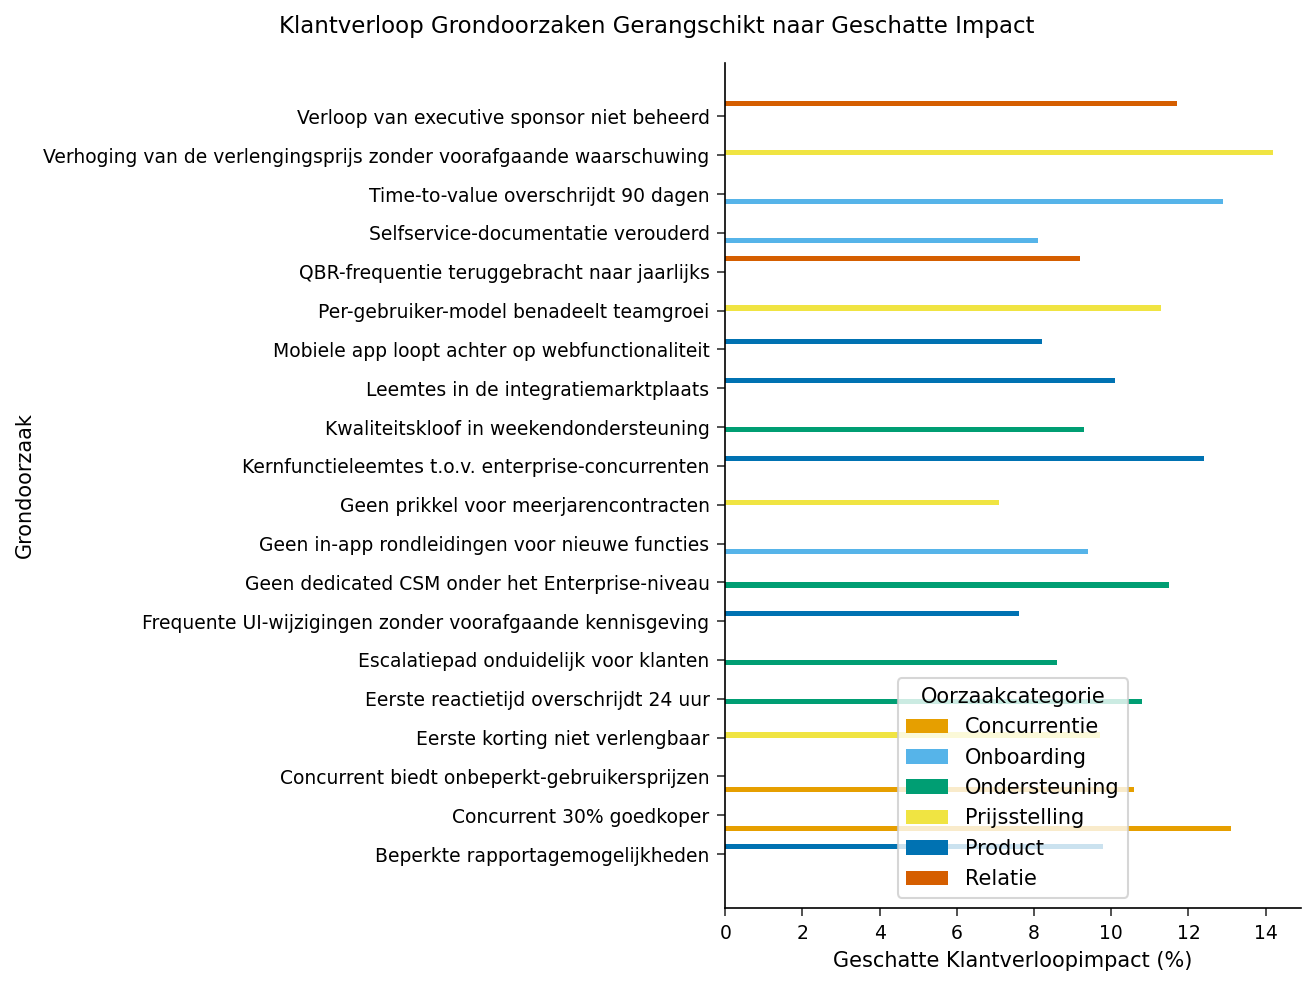

In [3]:
/* --------------------------------------------------------
   Pareto-weergave: individuele grondoorzaken gerangschikt naar
   geschatte klantverloopimpact, gekleurd per categorie. Dit
   vult de visgraat aan door te kwantificeren welke beenderen
   het belangrijkst zijn.
   -------------------------------------------------------- */
PROCEDURE SORTEREN GEGEVENS=work.churn_rca;
    VOLGENS AFLOPEND churn_impact_pct;
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    XAXIS label='Geschatte Klantverloopimpact (%)';
    YAXIS label='Grondoorzaak' discreteorder=data;
    keylegend / title='Oorzaakcategorie' position=bottom;
    TITEL 'Klantverloop Grondoorzaken Gerangschikt naar Geschatte Impact';
UITVOEREN;


---

### Oorzaak-en-gevolgdiagram (Ishikawa)

`PROC FISHBONE` bouwt het diagram rechtstreeks op vanuit `WORK.CHURN_RCA`: elke
afzonderlijke `category` wordt een hoofdbeen vanaf de centrale ruggengraat, en
de individuele `cause`-bevindingen hangen als subhoorzaken aan hun
categoriebeen. De procedure drukt hieronder de volledige
oorzaak-en-gevolgstructuur af — het gevolg aan het hoofd, de zes
categoriebeenderen, en elke subhoorzaak gegroepeerd onder zijn been — en
schrijft de bijbehorende visgraatafbeelding naar schijf. De gerangschikte
Pareto-grafiek hierboven is de aanvullende weergave die kwantificeert welke
van deze beenderen het meeste toewijsbare klantverloop draagt.

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE: oorzaak-en-gevolgdiagram van klantverloop.
   Het diagram wordt rechtstreeks aangestuurd vanuit
   WORK.CHURN_RCA, dus de zes oorzaakcategorieen en hun
   oorzaken zijn precies de hierboven geanalyseerde bevindingen.
   CATEGORY vormt de hoofdbeenderen; CAUSE hangt als subhoorzaken
   aan elk been.
   -------------------------------------------------------- */
PROCEDURE fishbone GEGEVENS=work.churn_rca;
    cause category / subcause=cause;
    effect 'Verhoogd Klantverloop (18% jaarlijks vs. 8% doel)';
    TITEL 'Klantverloop Grondoorzaakanalyse - Segment Middensegment';
    footnote 'Bronnen: exit-interviews, CS-teaminterviews, cohortattributie';
UITVOEREN;


                                    Klantverloop RCA: Impactpercentage per Categorie                                    


                    Klantverloop Grondoorzaakanalyse - Segment Middensegment
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] Verhoogd Klantverloop (18% jaarlijks vs. 8% doel)
    [CAUSE] Prijsstelling (top)
      [SUB] Verhoging van de verlengingsprijs zonder voorafgaande waarschuwing
      [SUB] Per-gebruiker-model benadeelt teamgroei
      [SUB] Eerste korting niet verlengbaar
      [SUB] Geen prikkel voor meerjarencontracten
    [CAUSE] Concurrentie (top)
      [SUB] Concurrent 30% goedkoper
      [SUB] Concurrent biedt onbeperkt-gebruikersprijzen
    [CAUSE] Onboarding (top)
      [SUB] Time-to-value overschrijdt 90 dagen
      [SUB] Geen in-app rondleidingen voor nieuwe functies
      [SUB] Selfservice-documentatie verouderd
    [CAUSE] Product (bottom)
      [SUB] Kernfunctieleemtes t.o.v. enterprise-concurrenten
      [SUB]


NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### Interpretatie

De oorzaak-en-gevolgstructuur en de `PROC MEANS`-cijfers per categorie wijzen
het leiderschap naar een klein aantal ingrepen met hoog hefboomeffect. De twee
bevindingen met de hoogste individuele impact — de prijsverhoging bij
verlenging zonder waarschuwing bij **Prijsstelling** (14,2) en de bevinding
bij **Concurrentie** dat een rivaal gelijkwaardige functionaliteit verkoopt
voor 30% lagere prijs (13,1) — zijn beide commerciële kwesties in plaats van
productkwesties, wat erop wijst dat prijstransparantie en
concurrentiepositionering de meest urgente hefbomen op korte termijn zijn. De
**Onboarding**-bevinding dat de time-to-value langer is dan 90 dagen (12,9) is
de grootste bevinding aan de servicekant en hangt rechtstreeks samen met
verwachtingsmanagement voorafgaand aan de verkoop.

Qua volume domineert **Product** het diagram (5 van de 20 bevindingen, 48,1
totale impactpunten), maar de bevindingen zijn individueel kleiner (gemiddelde
9,6) dan die bij **Concurrentie** (gemiddelde 11,8) of **Prijsstelling**
(gemiddelde 10,6) — een herinnering dat een lange lijst productleemtes niet
automatisch de hoogste prioriteit is. Het been **Relatie** (verloop van de
executive sponsor en teruggebrachte QBR-frequentie, samen 20,9) vertegenwoordigt
procesveranderingen die het CS-team binnen het huidige kwartaal kan doorvoeren
zonder investering in product of prijsstelling, en biedt zo het snelste pad
naar meetbare verbetering van klantbehoud. De volledige gerangschikte lijst in
de Pareto-grafiek stelt het leiderschapsteam in staat interventies te
sequencen op geschatte impact in plaats van op categoriegrootte.

---

In [5]:
/* --------------------------------------------------------
   Exporteer de RCA-bevindingen van klantverloop voor de
   strategiebeoordeling
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REPLACE;
UITVOEREN;



NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>